The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading dataset: 
integer_len32_SIZE_250 from 
/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/Projects/AGNEWS/data



/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/counterfactual_alignment/utilities.py:2087: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider = Slider(slider_ax, "Epoch", 0, 0, valinit=0, valstep=1)
/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/counterfactual_alignment/utilities.py:2087: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider = Slider(slider_ax, "Epoch", 0, 0, valinit=0, valstep=1)
/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/counterfactual_alignment/utilities.py:2087: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider = Slider(slider_ax, "Epoch", 0, 0, valinit=0, valstep=1)


dict_keys(['model', 'params', 'results'])
Using t-SNE...


/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/counterfactual_alignment/utilities.py:2138: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider.ax.set_xlim(0, max_epoch)


dict_keys(['model', 'params', 'results'])
Using t-SNE...


/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/counterfactual_alignment/utilities.py:2138: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider.ax.set_xlim(0, max_epoch)


dict_keys(['model', 'params', 'results'])
Using t-SNE...


/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/counterfactual_alignment/utilities.py:2138: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider.ax.set_xlim(0, max_epoch)


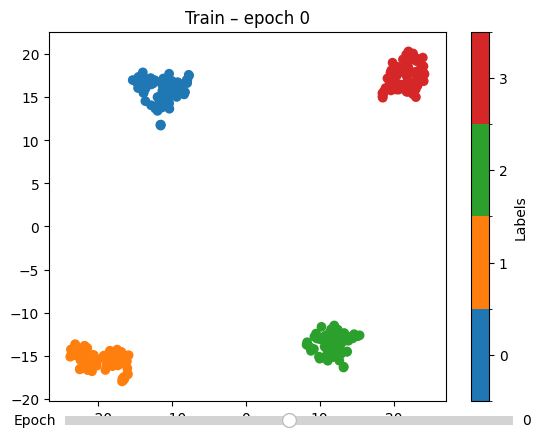

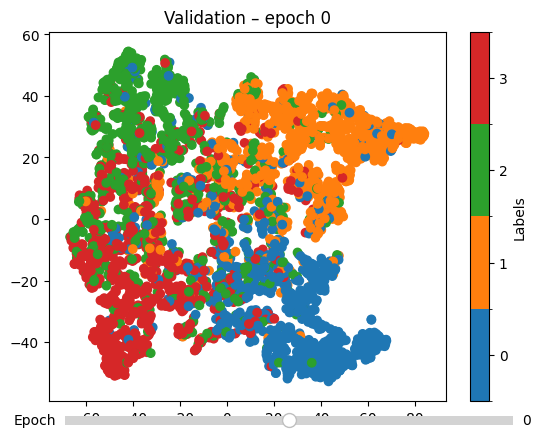

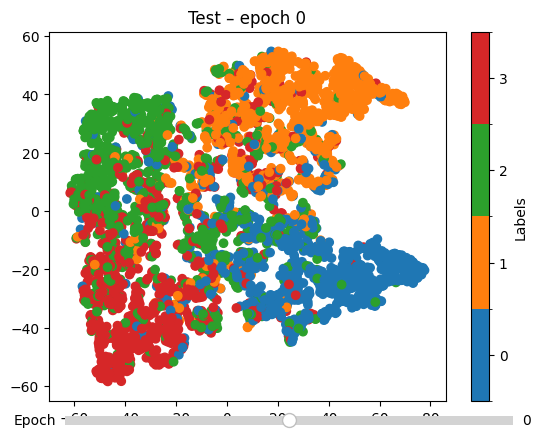

In [20]:
# Pipeline:
#  Define a neural net
#  Create a dataset to train on. Standard classifier example, or maybe XOR (or both)
#  Create a function script which enables either Cross-entropy or Direction loss function [ESSENTIAL]
#  Training model on the dataset on set of training points (very few -> 100% accuracy) [ESSENTIAL]
## Standard libraries
import numpy as np
import random
import pickle
import yaml
import matplotlib.pyplot as plt
## Progress bar
from tqdm.auto import tqdm

#ML Libraries
import jax
import optax
import torch

import os
from functools import partial
import argparse

import torch.utils.data as data

# Custom Libraries
from counterfactual_alignment.custom_models   import SimpleClassifier, MLP, CNN,  GSPaper, GSPaperNew, GSPaper2, GSPaper3, BagOfWordsClassifier, BagOfWordsClassifierSimple, BagOfWordsClassifier2Layer, BagOfWordsClassifierSingle, SentimentModel
from counterfactual_alignment.custom_models   import custom_models
from counterfactual_alignment.custom_datasets import customDataset
from counterfactual_alignment.loss_functions import loss_functions
from counterfactual_alignment.knowledge_functions import knowledge_functions
import counterfactual_alignment.utilities as utils
from counterfactual_alignment.utilities import (visualise_classes, mnist_collate_beta, sst_collate, select_informative_samples,
                        reduce_dataset, compute_metrics, generate_results, generate_results_ensemble, create_train_state, boundary_filter, save_stats, train_one_epoch, combine_datasets)

%load_ext autoreload
%autoreload 2
from counterfactual_alignment.utilities import visualise_embeddings
import pickle as pkl
import os

config_path = os.path.join(os.getcwd(),'config.yaml')


with open(config_path,'r') as file:
    config = yaml.unsafe_load(file)



"""
Load DATASET
"""
# Build path to "data" folder inside that directory
data_folder = os.path.join(os.getcwd(), 'data')

data_name = config['data_params']['dataset']

print(f"Loading dataset: \n{data_name} from \n{data_folder}\n")

with open(os.path.join(data_folder,data_name)+'.pkl', 'rb') as file:
    datasets = pickle.load(file)


n_classes = datasets['n_classes']


n_vectors = len(datasets['train']['original']['X'][0])
train_size = len(datasets['train']['original']['Y'])

rng = jax.random.PRNGKey(42)
rng, inp_rng, init_rng, dropout_rng, embedding_rng = jax.random.split(rng, 5)



"""
Load embeddings and convert into pipeline datasets
"""

if config['data_params']['control']:
    full_training_set = customDataset(combine_datasets(datasets['control']['original'], datasets['control']['original']))
else: 
    full_training_set = customDataset(datasets['train']['original'])
    # Filter out any case where counterfactual is the same as the original
if False:
    filter_indices = []
    for i in range(len(full_training_set)):
        if np.all(training_set.K['vector'][i]) == 0:
            filter_indices.append(i)

    filter_indices = sorted(filter_indices, reverse=True)

    for i in filter_indices:
        training_set.drop(i)
    
    print(f"Train dataset reduced to {len(training_set)} samples.")

training_set = full_training_set
validation = customDataset(datasets['dev']['original'])
test_original = customDataset(datasets['test']['original'])

datasets = {
    'Train': training_set,
    'Validation': validation,
    'Test': test_original
}



"""Load Model"""
path ="/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/Projects/AGNEWS/model_outputs/integer_len32_SIZE_250"

model = "MODEL_ENSEMBLE_6_BagOfWordsClassifierMultiClass__emb64_OPTIM_adabelief__LR_0.001__BATCHSIZE_32__trainsize_250__active_False_smplsize_5_div0.8_LOSS_multiclass_cross_entropy_mix_0.3.pkl"
# /Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment-cli/Projects/AGNEWS/model_outputs/integer_len32_SIZE_250/MODEL_ENSEMBLE_6_BagOfWordsClassifierMultiClass__emb64_OPTIM_adabelief__LR_0.001__BATCHSIZE_32__trainsize_250__active_False_smplsize_5_div0.8_LOSS_multiclass_cross_entropy_mix_0.3.pkl
with open(os.path.join(path,model),'rb') as f:
    model_data = pkl.load(f)


visualise_embeddings(datasets,model_data)